In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
import os

dataset_path = '/content/drive/MyDrive/EuroSplitFinalnaJud/val'

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        print(f"{class_name}: {len(images)} images")

HerbaceousVegetation: 450 images
Industrial: 375 images
AnnualCrop: 450 images
Forest: 450 images
Highway: 375 images
Pasture: 300 images
PermanentCrop: 375 images
Residential: 450 images
SeaLake: 450 images
River: 375 images


In [13]:
!mkdir -p /content/local_data    # Creates a fresh one

In [14]:
!cp -r /content/drive/MyDrive/EuroSplitFinalnaJud/* /content/local_data/

In [17]:
!find /content/local_data -type f | wc -l

27000


In [18]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [19]:
dataset_path = '/content/local_data'
train_dir = f'{dataset_path}/train'
val_dir   = f'{dataset_path}/val'
test_dir  = f'{dataset_path}/test'

In [20]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 18900 images belonging to 10 classes.
Found 4050 images belonging to 10 classes.


In [21]:
checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [22]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [23]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=12,
    callbacks=[checkpoint, early_stop, lr_scheduler]
)

Epoch 1/12
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.7894 - loss: 0.6253
Epoch 1: val_accuracy improved from None to 0.90963, saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5



Epoch 1: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5
591/591 ━━━━━━━━━━━━━━━━━━━━ 299s 479ms/step - accuracy: 0.8585 - loss: 0.4143 - val_accuracy: 0.9096 - val_loss: 0.2598 - learning_rate: 0.0010
Epoch 2/12
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step - accuracy: 0.9125 - loss: 0.2600
Epoch 2: val_accuracy improved from 0.90963 to 0.93531, saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5



Epoch 2: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5
591/591 ━━━━━━━━━━━━━━━━━━━━ 301s 510ms/step - accuracy: 0.9127 - loss: 0.2565 - val_accuracy: 0.9353 - val_loss: 0.1999 - learning_rate: 0.0010
Epoch 3/12
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.9219 - loss: 0.2252
Epoch 3: val_accuracy improved from 0.93531 to 0.94395, saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5



Epoch 3: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5
591/591 ━━━━━━━━━━━━━━━━━━━━ 308s 521ms/step - accuracy: 0.9186 - loss: 0.2327 - val_accuracy: 0.9440 - val_loss: 0.1759 - learning_rate: 0.0010
Epoch 4/12
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step - accuracy: 0.9253 - loss: 0.2147
Epoch 4: val_accuracy did not improve from 0.94395
591/591 ━━━━━━━━━━━━━━━━━━━━ 290s 490ms/step - accuracy: 0.9253 - loss: 0.2139 - val_accuracy: 0.9351 - val_loss: 0.1944 - learning_rate: 0.0010
Epoch 5/12
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step - accuracy: 0.9307 - loss: 0.2073
Epoch 5: val_accuracy improved from 0.94395 to 0.94494, saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5



Epoch 5: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5
591/591 ━━━━━━━━━━━━━━━━━━━━ 283s 479ms/step - accuracy: 0.9317 - loss: 0.2017 - val_accuracy: 0.9449 - val_loss: 0.1696 - learning_rate: 0.0010
Epoch 6/12
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9351 - loss: 0.1860
Epoch 6: val_accuracy did not improve from 0.94494
591/591 ━━━━━━━━━━━━━━━━━━━━ 263s 445ms/step - accuracy: 0.9362 - loss: 0.1818 - val_accuracy: 0.9378 - val_loss: 0.1956 - learning_rate: 0.0010
Epoch 7/12
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.9399 - loss: 0.1797
Epoch 7: val_accuracy did not improve from 0.94494
591/591 ━━━━━━━━━━━━━━━━━━━━ 264s 447ms/step - accuracy: 0.9399 - loss: 0.1774 - val_accuracy: 0.9422 - val_loss: 0.1800 - learning_rate: 0.0010
Epoch 8/12
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9410 - loss: 0.1734
Epoch 8: val_accuracy did not improve from 0.94494

Epoch 8: ReduceLROnPlateau reducing learning rate t


Epoch 9: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5
591/591 ━━━━━━━━━━━━━━━━━━━━ 265s 448ms/step - accuracy: 0.9508 - loss: 0.1374 - val_accuracy: 0.9533 - val_loss: 0.1448 - learning_rate: 3.0000e-04
Epoch 10/12
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.9547 - loss: 0.1213
Epoch 10: val_accuracy improved from 0.95333 to 0.95605, saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5



Epoch 10: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5
591/591 ━━━━━━━━━━━━━━━━━━━━ 265s 448ms/step - accuracy: 0.9572 - loss: 0.1217 - val_accuracy: 0.9560 - val_loss: 0.1385 - learning_rate: 3.0000e-04
Epoch 11/12
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9572 - loss: 0.1198
Epoch 11: val_accuracy did not improve from 0.95605
591/591 ━━━━━━━━━━━━━━━━━━━━ 257s 435ms/step - accuracy: 0.9590 - loss: 0.1184 - val_accuracy: 0.9546 - val_loss: 0.1464 - learning_rate: 3.0000e-04
Epoch 12/12
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9608 - loss: 0.1100
Epoch 12: val_accuracy did not improve from 0.95605
591/591 ━━━━━━━━━━━━━━━━━━━━ 252s 426ms/step - accuracy: 0.9612 - loss: 0.1137 - val_accuracy: 0.9516 - val_loss: 0.1476 - learning_rate: 3.0000e-04


In [25]:
base_model.trainable = True

for layer in base_model.layers[:-100]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [26]:
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[checkpoint, early_stop, lr_scheduler]
)

Epoch 1/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.8927 - loss: 0.3452
Epoch 1: val_accuracy improved from 0.95605 to 0.96321, saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5



Epoch 1: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5
591/591 ━━━━━━━━━━━━━━━━━━━━ 341s 512ms/step - accuracy: 0.9166 - loss: 0.2591 - val_accuracy: 0.9632 - val_loss: 0.1269 - learning_rate: 1.0000e-05
Epoch 2/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.9501 - loss: 0.1533
Epoch 2: val_accuracy improved from 0.96321 to 0.97037, saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5



Epoch 2: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5
591/591 ━━━━━━━━━━━━━━━━━━━━ 295s 499ms/step - accuracy: 0.9513 - loss: 0.1513 - val_accuracy: 0.9704 - val_loss: 0.1006 - learning_rate: 1.0000e-05
Epoch 3/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.9613 - loss: 0.1198
Epoch 3: val_accuracy improved from 0.97037 to 0.97284, saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5



Epoch 3: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5
591/591 ━━━━━━━━━━━━━━━━━━━━ 290s 491ms/step - accuracy: 0.9611 - loss: 0.1185 - val_accuracy: 0.9728 - val_loss: 0.0899 - learning_rate: 1.0000e-05
Epoch 4/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 485ms/step - accuracy: 0.9705 - loss: 0.0900
Epoch 4: val_accuracy improved from 0.97284 to 0.97407, saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5



Epoch 4: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5
591/591 ━━━━━━━━━━━━━━━━━━━━ 305s 516ms/step - accuracy: 0.9675 - loss: 0.0972 - val_accuracy: 0.9741 - val_loss: 0.0944 - learning_rate: 1.0000e-05
Epoch 5/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.9721 - loss: 0.0860
Epoch 5: val_accuracy improved from 0.97407 to 0.97580, saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5



Epoch 5: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5
591/591 ━━━━━━━━━━━━━━━━━━━━ 315s 533ms/step - accuracy: 0.9726 - loss: 0.0846 - val_accuracy: 0.9758 - val_loss: 0.0837 - learning_rate: 1.0000e-05
Epoch 6/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.9754 - loss: 0.0687
Epoch 6: val_accuracy improved from 0.97580 to 0.97704, saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5



Epoch 6: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5
591/591 ━━━━━━━━━━━━━━━━━━━━ 313s 530ms/step - accuracy: 0.9748 - loss: 0.0733 - val_accuracy: 0.9770 - val_loss: 0.0835 - learning_rate: 1.0000e-05
Epoch 7/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.9779 - loss: 0.0659
Epoch 7: val_accuracy did not improve from 0.97704
591/591 ━━━━━━━━━━━━━━━━━━━━ 312s 527ms/step - accuracy: 0.9777 - loss: 0.0678 - val_accuracy: 0.9748 - val_loss: 0.0844 - learning_rate: 1.0000e-05
Epoch 8/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.9802 - loss: 0.0562
Epoch 8: val_accuracy improved from 0.97704 to 0.98123, saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5



Epoch 8: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5
591/591 ━━━━━━━━━━━━━━━━━━━━ 314s 532ms/step - accuracy: 0.9812 - loss: 0.0557 - val_accuracy: 0.9812 - val_loss: 0.0790 - learning_rate: 1.0000e-05
Epoch 9/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 509ms/step - accuracy: 0.9846 - loss: 0.0476
Epoch 9: val_accuracy did not improve from 0.98123
591/591 ━━━━━━━━━━━━━━━━━━━━ 313s 530ms/step - accuracy: 0.9824 - loss: 0.0537 - val_accuracy: 0.9780 - val_loss: 0.0792 - learning_rate: 1.0000e-05
Epoch 10/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.9845 - loss: 0.0485
Epoch 10: val_accuracy did not improve from 0.98123
591/591 ━━━━━━━━━━━━━━━━━━━━ 308s 521ms/step - accuracy: 0.9840 - loss: 0.0493 - val_accuracy: 0.9802 - val_loss: 0.0799 - learning_rate: 1.0000e-05
Epoch 11/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - accuracy: 0.9827 - loss: 0.0508
Epoch 11: val_accuracy improved from 0.98123 to 0.98148, saving model to /content/drive/


Epoch 11: finished saving model to /content/drive/MyDrive/EuroSplitFinalnaJud/ResNet50_best3.h5

Epoch 11: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
591/591 ━━━━━━━━━━━━━━━━━━━━ 312s 528ms/step - accuracy: 0.9858 - loss: 0.0438 - val_accuracy: 0.9815 - val_loss: 0.0885 - learning_rate: 1.0000e-05
Epoch 12/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 515ms/step - accuracy: 0.9887 - loss: 0.0351
Epoch 12: val_accuracy did not improve from 0.98148
591/591 ━━━━━━━━━━━━━━━━━━━━ 317s 536ms/step - accuracy: 0.9882 - loss: 0.0357 - val_accuracy: 0.9798 - val_loss: 0.0818 - learning_rate: 3.0000e-06
Epoch 13/20
591/591 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.9889 - loss: 0.0346
Epoch 13: val_accuracy did not improve from 0.98148
591/591 ━━━━━━━━━━━━━━━━━━━━ 311s 526ms/step - accuracy: 0.9888 - loss: 0.0335 - val_accuracy: 0.9815 - val_loss: 0.0791 - learning_rate: 3.0000e-06


In [27]:
model.save('/content/drive/MyDrive/EuroDataset/ResNet50_final3.h5')

print("Improved ResNet50 model saved!")

Improved ResNet50 model saved!


In [28]:
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 4050 images belonging to 10 classes.


In [29]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

127/127 ━━━━━━━━━━━━━━━━━━━━ 12s 97ms/step - accuracy: 0.9802 - loss: 0.0589
Test Accuracy: 0.980246901512146
Test Loss: 0.05890033394098282


In [30]:
import numpy as np

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = test_generator.classes

127/127 ━━━━━━━━━━━━━━━━━━━━ 27s 174ms/step


In [34]:
from sklearn.metrics import classification_report
class_names = list(train_generator.class_indices.keys())
# Define all labels explicitly
all_labels = list(range(len(class_names)))  # [0,1,2,...,9]

print(classification_report(
    y_true,
    y_pred_classes,
    labels=all_labels,      # include all classes
    target_names=class_names,
    zero_division=0          # avoids division by zero warning
))

                      precision    recall  f1-score   support

          AnnualCrop       0.97      0.97      0.97       450
              Forest       0.99      0.99      0.99       450
HerbaceousVegetation       0.97      0.96      0.97       450
             Highway       0.98      0.98      0.98       375
          Industrial       0.99      0.99      0.99       375
             Pasture       0.97      0.96      0.96       300
       PermanentCrop       0.96      0.96      0.96       375
         Residential       0.99      1.00      0.99       450
               River       0.99      0.98      0.99       375
             SeaLake       0.99      1.00      1.00       450

            accuracy                           0.98      4050
           macro avg       0.98      0.98      0.98      4050
        weighted avg       0.98      0.98      0.98      4050



127/127 ━━━━━━━━━━━━━━━━━━━━ 15s 114ms/step


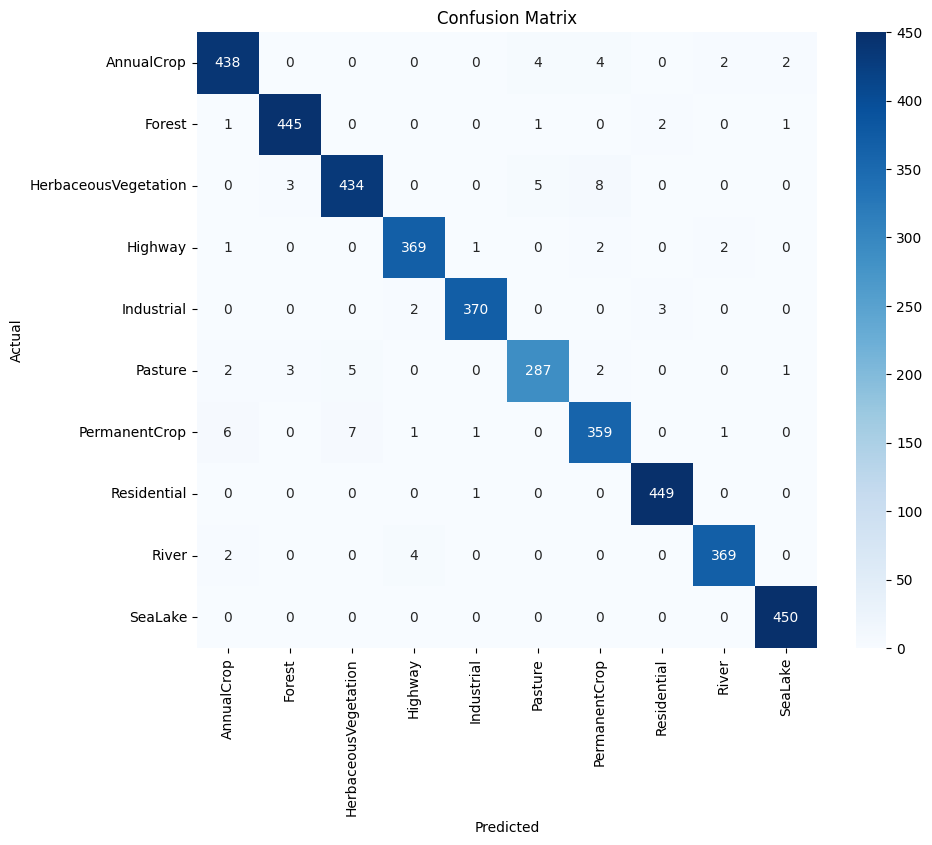

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()